# YOLO-Based Object Trajectory Prediction with MLP

This project uses a pretrained YOLO model to detect and track objects in a video.  
The first stage focuses on loading a video, running YOLO object detection, and checking whether the model can correctly detect a walking person.

Current goal:

1. Load a pretrained YOLO model
2. Read the input video from `video_data`
3. Run basic object detection
4. Display and save the detection result


In [1]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.predict(
    source="video_data/video.mp4",
    show=True,
    save=True,
    conf=0.5,
    project="results",
    name="detect_test",
    exist_ok=True
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/516) d:\DL\PyTorch\MLP_(Multi-Layer Perceptron)\YOLO-Based Object Trajectory Prediction with MLP\video_data\video.mp4: 640x384 14 persons, 1 handbag, 43.3ms
video 1/1 (frame 2/516) d:\DL\PyTorch\MLP_(Multi-Layer Perceptron)\YOLO-Based Object Trajectory Prediction with MLP\video_data\video.mp4: 640x384 14 persons, 1 handbag, 12.1ms
video 1/1 (frame 3/516) d:\DL\PyTorch\MLP_(Multi-Layer Perceptron)\YOLO-Based Object Trajectory Prediction wi

In this step, we use the same pretrained YOLO model to track objects across video frames.

Unlike basic detection, tracking assigns an ID to each object.  
This allows us to follow the same person over time and later save the object center points as trajectory data.

In [2]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.track(
    source="video_data/video.mp4",
    show=True,
    save=True,
    conf=0.5,
    persist=True,
    project="results",
    name="track_test",
    exist_ok=True
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/516) d:\DL\PyTorch\MLP_(Multi-Layer Perceptron)\YOLO-Based Object Trajectory Prediction with MLP\video_data\video.mp4: 640x384 14 persons, 1 handbag, 36.2ms
video 1/1 (frame 2/516) d:\DL\PyTorch\MLP_(Multi-Layer Perceptron)\YOLO-Based Object Trajectory Prediction with MLP\video_data\video.mp4: 640x384 14 persons, 1 handbag, 35.9ms
video 1/1 (frame 3/516) d:\DL\PyTorch\MLP_(Multi-Layer Perceptron)\YOLO-Based Object Trajectory Prediction wi

In this step, YOLO tracking results are converted into structured trajectory data.

For each detected object, saving the tracking ID, class name, confidence score, bounding box coordinates, center point, and box area.

The center point data will be used later for object trajectory prediction with an MLP model.

In [3]:
import csv
import cv2
from pathlib import Path
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

video_path = "video_data/video.mp4"
csv_path = "results/tracking_results.csv"

Path("results").mkdir(exist_ok=True)

cap = cv2.VideoCapture(video_path)

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "frame",
        "track_id",
        "class_name",
        "confidence",
        "x1",
        "y1",
        "x2",
        "y2",
        "center_x",
        "center_y",
        "box_width",
        "box_height",
        "box_area"
    ])

    frame_id = 0

    while cap.isOpened(): 
        success, frame = cap.read() 

        if not success:
            break

        results = model.track(
            frame,
            persist=True,
            conf=0.5,
            verbose=False
        )

        result = results[0]

        if result.boxes is not None and result.boxes.id is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
            track_ids = result.boxes.id.cpu().numpy().astype(int)
            class_ids = result.boxes.cls.cpu().numpy().astype(int)
            confs = result.boxes.conf.cpu().numpy()

            for box, track_id, class_id, conf in zip(boxes, track_ids, class_ids, confs):
                x1, y1, x2, y2 = box

                box_width = x2 - x1
                box_height = y2 - y1
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2
                box_area = box_width * box_height
                class_name = model.names[class_id]

                writer.writerow([
                    frame_id,
                    track_id,
                    class_name,
                    round(float(conf), 4),
                    round(float(x1), 2),
                    round(float(y1), 2),
                    round(float(x2), 2),
                    round(float(y2), 2),
                    round(float(center_x), 2),
                    round(float(center_y), 2),
                    round(float(box_width), 2),
                    round(float(box_height), 2),
                    round(float(box_area), 2)
                ])

        frame_id += 1

cap.release()

print(f"Saved tracking results to {csv_path}")

Saved tracking results to results/tracking_results.csv


In [4]:
import pandas as pd

# Read the tracking results CSV file
df = pd.read_csv("results/tracking_results.csv")
df.head()

# Count the occurrences of each track_id in the DataFrame
df["track_id"].value_counts()

track_id
13    495
10    492
31    413
9     310
7     288
39    272
2     256
36    246
4     231
16    197
12    164
1     147
6     140
5      89
53     58
8      55
3      51
11     43
43     38
33     27
44     23
50     23
55     23
52     19
29     14
48      8
54      8
14      6
56      6
21      5
15      2
38      2
34      1
35      1
40      1
42      1
Name: count, dtype: int64

After generating the tracking CSV file, we need to inspect the tracking results.

The raw CSV may contain multiple detected objects and multiple tracking IDs.  
For trajectory prediction, we first select the main walking person and keep only one stable track ID.

In this step, we will:

1. Load the tracking CSV file
2. Check the detected classes
3. Count how many frames each tracking ID appears in
4. Select the main person track
5. Save the cleaned trajectory data

In [5]:
# Filter the DataFrame to include only rows where the class_name is "person"
person_df = df[df["class_name"] == "person"]

person_df.head()

,frame,track_id,class_name,confidence,x1,y1,x2,y2,center_x,center_y,box_width,box_height,box_area
0,0,1,person,0.8985,95.53,815.07,238.19,1182.70,166.86,998.89,142.66,367.63,52444.24
1,0,2,person,0.8961,488.76,448.32,641.56,783.20,565.16,615.76,152.80,334.88,51170.05
2,0,3,person,0.8858,593.21,1387.79,805.68,1785.17,699.45,1586.48,212.47,397.38,84429.24
3,0,4,person,0.8736,618.65,285.14,748.72,613.66,683.68,449.40,130.07,328.52,42732.17
4,0,5,person,0.8665,705.96,966.42,838.63,1296.20,772.29,1131.31,132.67,329.79,43754.11


In [6]:
person_df["track_id"].value_counts()

track_id
13    495
10    492
31    413
9     310
7     288
39    272
2     256
4     231
16    197
12    164
1     147
6     140
5      89
53     58
8      55
3      51
11     43
15      2
Name: count, dtype: int64

In [7]:
# Find the track_id with the maximum count for the "person" class
main_id = person_df["track_id"].value_counts().idxmax()

main_id

np.int64(13)

In [8]:
# Filter the DataFrame to include only rows with the main_id
main_track = person_df[person_df["track_id"] == main_id].copy()

main_track.head()

,frame,track_id,class_name,confidence,x1,y1,x2,y2,center_x,center_y,box_width,box_height,box_area
12,0,13,person,0.7961,30.11,0.00,108.90,185.92,69.50,92.96,78.78,185.92,14647.53
27,1,13,person,0.7601,30.44,0.54,109.84,188.09,70.14,94.31,79.41,187.56,14893.55
42,2,13,person,0.7847,31.15,0.75,110.00,187.50,70.58,94.13,78.84,186.75,14724.03
56,3,13,person,0.7975,31.92,0.74,110.28,188.05,71.10,94.40,78.37,187.31,14678.85
69,4,13,person,0.7867,32.56,0.79,110.76,191.73,71.66,96.26,78.19,190.95,14930.82


In [9]:
# Select the relevant columns for the main track
main_track = main_track[
    [
        "frame",
        "track_id",
        "center_x",
        "center_y",
        "box_area",
        "confidence"
    ]
]

main_track.head()

,frame,track_id,center_x,center_y,box_area,confidence
12,0,13,69.50,92.96,14647.53,0.7961
27,1,13,70.14,94.31,14893.55,0.7601
42,2,13,70.58,94.13,14724.03,0.7847
56,3,13,71.10,94.40,14678.85,0.7975
69,4,13,71.66,96.26,14930.82,0.7867


In [10]:
main_track.to_csv("results/main_person_track.csv", index=False)

print("Saved cleaned track to results/main_person_track.csv")

Saved cleaned track to results/main_person_track.csv


In [11]:
df = pd.read_csv("results/main_person_track.csv")

cap = cv2.VideoCapture("video_data/video.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

df["time"] = df["frame"] / fps

df.to_csv("results/main_person_track.csv", index=False)

df.head()

,frame,track_id,center_x,center_y,box_area,confidence,time
0,0,13,69.50,92.96,14647.53,0.7961,0.00
1,1,13,70.14,94.31,14893.55,0.7601,0.04
2,2,13,70.58,94.13,14724.03,0.7847,0.08
3,3,13,71.10,94.40,14678.85,0.7975,0.12
4,4,13,71.66,96.26,14930.82,0.7867,0.16


## Visualize the Object Trajectory

Before training the MLP model, we first visualize the cleaned tracking data.

This helps us check whether the selected track is stable and whether the object center points form a reasonable motion trajectory.

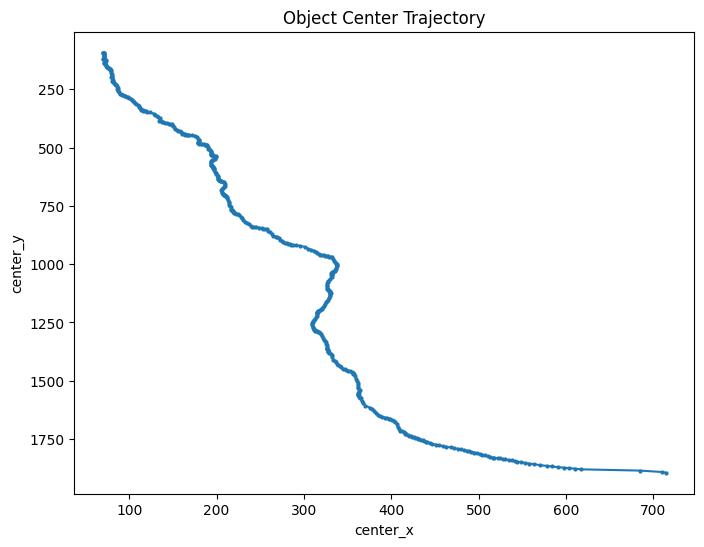

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/main_person_track.csv")

plt.figure(figsize=(8, 6))
plt.plot(df["center_x"], df["center_y"], marker="o", markersize=2)
plt.xlabel("center_x")
plt.ylabel("center_y")
plt.title("Object Center Trajectory")
plt.gca().invert_yaxis()
plt.show()

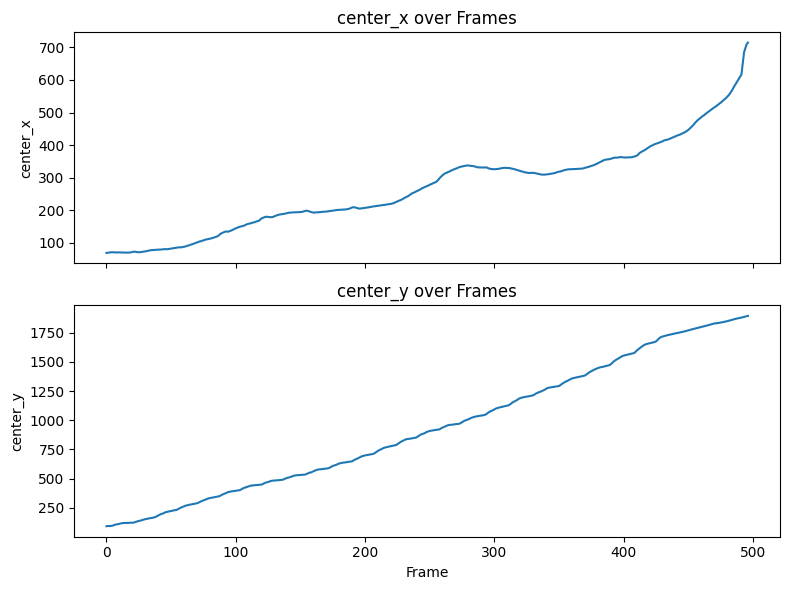

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(df["frame"], df["center_x"])
axes[0].set_ylabel("center_x")
axes[0].set_title("center_x over Frames")

axes[1].plot(df["frame"], df["center_y"])
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("center_y")
axes[1].set_title("center_y over Frames")

plt.tight_layout()
plt.show()

## Prepare Trajectory Data for MLP

The cleaned tracking data contains the center point of the tracked person in each frame.

To train an MLP model, we convert the trajectory into supervised learning data.

The input is the center positions from the previous several frames, and the target is the center position of the next frame.

For example:

Input:
frame 0 to frame 4 center points

Target:
frame 5 center point

In [14]:
import numpy as np

df = pd.read_csv("results/main_person_track.csv")

cap = cv2.VideoCapture("video_data/video.mp4")
video_width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
video_height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
cap.release()

# Normalize the center_x and center_y coordinates by dividing by the video width and height, respectively
df["center_x_norm"] = df["center_x"] / video_width
df["center_y_norm"] = df["center_y"] / video_height

sequence_length = 10

positions = df[["center_x_norm", "center_y_norm"]].values

X = []
y = []

for i in range(len(positions) - sequence_length):
    X.append(positions[i:i + sequence_length].flatten())
    y.append(positions[i + sequence_length])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape) # input features
print("y shape:", y.shape) # output features (next position)

X shape: (485, 20)
y shape: (485, 2)


## Split the Trajectory Data

The trajectory data is converted into input-output pairs for supervised learning.

Next, we split the data into training and testing sets.  
Because this is sequential video data, we do not randomly shuffle the samples.

The first 80% of the trajectory samples are used for training.  
The last 20% are used for testing the prediction performance.

In [15]:
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
y_train = y[:split_idx]

X_test = X[split_idx:]
y_test = y[split_idx:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (388, 20)
y_train shape: (388, 2)
X_test shape: (97, 20)
y_test shape: (97, 2)


## Test the MLP Model

In this step, we test whether the `TrajectoryMLP` model can be imported correctly from `model.py`.

The model should take an input with shape `(batch_size, 10)` and return an output with shape `(batch_size, 2)`.

Here, 10 represents the center coordinates from the previous 5 frames, and 2 represents the predicted next center point.

In [16]:
import torch
from model import TrajectoryMLP

model = TrajectoryMLP(input_size=10, hidden_size=64, output_size=2)

sample_input = torch.randn(4, 10)

sample_output = model(sample_input)

print("Input shape:", sample_input.shape)
print("Output shape:", sample_output.shape)

Input shape: torch.Size([4, 10])
Output shape: torch.Size([4, 2])


## Convert Data to PyTorch Tensors

The trajectory data was first prepared as NumPy arrays.

Before training the MLP model, the input data `X` and target data `y` need to be converted into PyTorch tensors.

The model will use `X` as input and learn to predict `y`.

In [17]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

print("X_tensor shape:", X_tensor.shape)
print("y_tensor shape:", y_tensor.shape)
print("X_tensor dtype:", X_tensor.dtype)
print("y_tensor dtype:", y_tensor.dtype)

X_tensor shape: torch.Size([485, 20])
y_tensor shape: torch.Size([485, 2])
X_tensor dtype: torch.float32
y_tensor dtype: torch.float32


## Train the MLP Model

Now we train the MLP model using the prepared trajectory data.

The model takes the center points from the previous 5 frames as input and predicts the center point of the next frame.

In [18]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [19]:
from model import TrajectoryMLP
from train import create_dataloaders, train

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataloader, test_dataloader = create_dataloaders(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    batch_size=32
)

model = TrajectoryMLP(
    input_size=20,
    hidden_size=64,
    output_size=2
).to(device)

loss_fn = torch.nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

results = train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=100,
    device=device
)

Epoch: 1 | train_loss: 0.0460 | test_loss: 0.1273
Epoch: 10 | train_loss: 0.0001 | test_loss: 0.0033
Epoch: 20 | train_loss: 0.0000 | test_loss: 0.0033
Epoch: 30 | train_loss: 0.0000 | test_loss: 0.0029
Epoch: 40 | train_loss: 0.0000 | test_loss: 0.0026
Epoch: 50 | train_loss: 0.0000 | test_loss: 0.0026
Epoch: 60 | train_loss: 0.0000 | test_loss: 0.0025
Epoch: 70 | train_loss: 0.0000 | test_loss: 0.0026
Epoch: 80 | train_loss: 0.0000 | test_loss: 0.0023
Epoch: 90 | train_loss: 0.0000 | test_loss: 0.0024
Epoch: 100 | train_loss: 0.0000 | test_loss: 0.0023


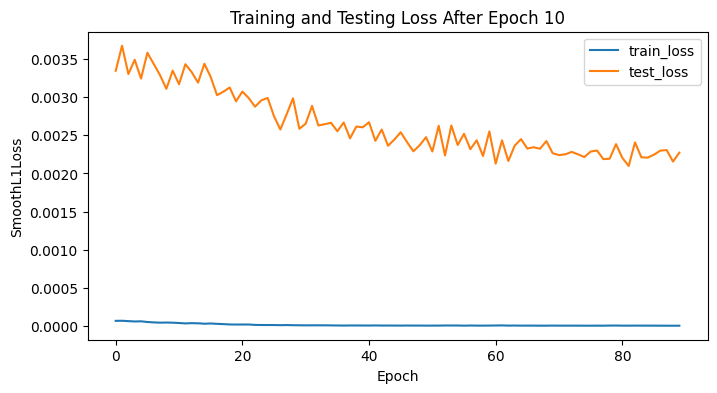

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(results["train_loss"][10:], label="train_loss")
plt.plot(results["test_loss"][10:], label="test_loss")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1Loss")
plt.title("Training and Testing Loss After Epoch 10")
plt.legend()
plt.show()

## Save the Trained MLP Model

After training the MLP model, we save the model weights so they can be reused later for trajectory prediction.

In [21]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)

torch.save(model.state_dict(), "models/trajectory_model.pth")

print("Saved model to models/trajectory_model.pth")

Saved model to models/trajectory_model.pth


## Make Predictions with the Trained MLP Model

After training and saving the MLP model, we use the test data to make trajectory predictions.

The model predicts normalized center coordinates, so the predictions need to be converted back to pixel coordinates before visualization.

In [22]:
model.eval()

with torch.inference_mode():
    y_pred = model(X_test.to(device)).cpu().numpy()

y_true = y_test.cpu().numpy()

print("y_pred shape:", y_pred.shape)
print("y_true shape:", y_true.shape)

y_pred shape: (97, 2)
y_true shape: (97, 2)


In [23]:
y_pred_pixel = y_pred.copy()
y_true_pixel = y_true.copy()

y_pred_pixel[:, 0] = y_pred_pixel[:, 0] * video_width
y_pred_pixel[:, 1] = y_pred_pixel[:, 1] * video_height

y_true_pixel[:, 0] = y_true_pixel[:, 0] * video_width
y_true_pixel[:, 1] = y_true_pixel[:, 1] * video_height

print(y_pred_pixel[:5])
print(y_true_pixel[:5])

[[     357.75      1538.6]
 [      358.2      1545.6]
 [     358.82      1552.5]
 [     359.37      1558.8]
 [     359.79      1564.9]]
[[     363.23      1545.2]
 [     362.99      1550.6]
 [     362.09      1554.7]
 [     362.07      1557.2]
 [     362.25      1559.5]]


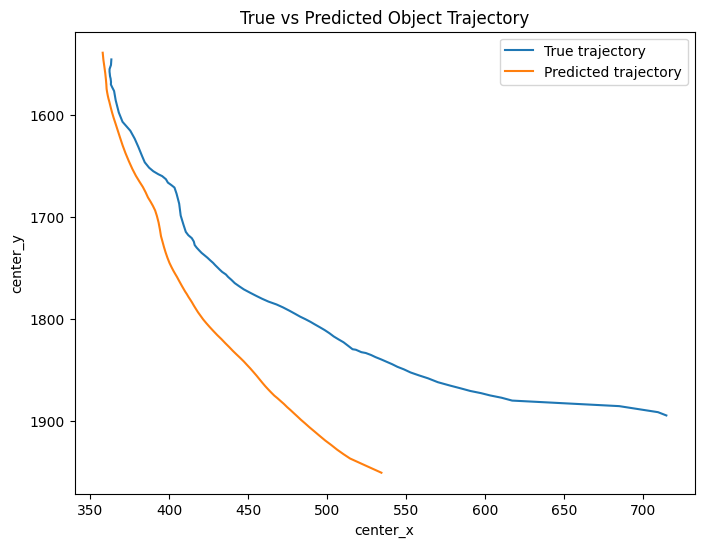

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(y_true_pixel[:, 0], y_true_pixel[:, 1], label="True trajectory")
plt.plot(y_pred_pixel[:, 0], y_pred_pixel[:, 1], label="Predicted trajectory")

plt.xlabel("center_x")
plt.ylabel("center_y")
plt.title("True vs Predicted Object Trajectory")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

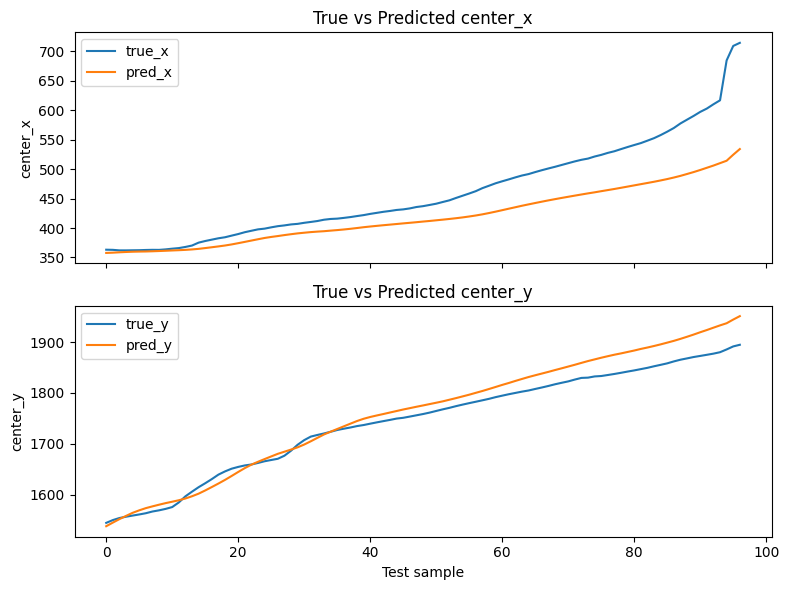

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(y_true_pixel[:, 0], label="true_x")
axes[0].plot(y_pred_pixel[:, 0], label="pred_x")
axes[0].set_ylabel("center_x")
axes[0].set_title("True vs Predicted center_x")
axes[0].legend()

axes[1].plot(y_true_pixel[:, 1], label="true_y")
axes[1].plot(y_pred_pixel[:, 1], label="pred_y")
axes[1].set_xlabel("Test sample")
axes[1].set_ylabel("center_y")
axes[1].set_title("True vs Predicted center_y")
axes[1].legend()

plt.tight_layout()
plt.show()

## Visualize Prediction Results

After running `predict.py`, we load the saved prediction results and visualize the true trajectory and predicted trajectory.

In [26]:
pred_df = pd.read_csv("results/prediction_results.csv")

pred_df.head()

,frame,true_x,true_y,pred_x,pred_y,error
0,398,363.22998,1545.1699,357.75565,1538.7460,8.440111
1,399,362.99002,1550.6200,358.19772,1545.7783,6.812336
2,400,362.09000,1554.6500,358.82388,1552.6461,3.831858
3,401,362.06998,1557.2300,359.37290,1558.9458,3.196607
4,402,362.25000,1559.4700,359.79010,1565.0015,6.053803


In [27]:
print("Mean error:", pred_df["error"].mean())
print("Max error:", pred_df["error"].max())

Mean error: 46.282377241237114
Max error: 191.7557


## Generate Prediction Demo Video

In this step, we overlay the MLP prediction results on the original video.

Green point: true object center  
Red point: predicted object center

The output video is saved as `results/prediction_demo.mp4`.

In [28]:
import cv2
import pandas as pd
from pathlib import Path

video_path = "video_data/video.mp4"
pred_path = "results/prediction_results.csv"
save_path = "results/prediction_demo.mp4"

pred_df = pd.read_csv(pred_path)
pred_dict = pred_df.set_index("frame").to_dict("index")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

Path("results").mkdir(exist_ok=True)

writer = cv2.VideoWriter(
    save_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

frame_id = 0

while cap.isOpened():
    success, frame = cap.read()

    if not success:
        break

    if frame_id in pred_dict:
        row = pred_dict[frame_id]

        true_x = int(row["true_x"])
        true_y = int(row["true_y"])
        pred_x = int(row["pred_x"])
        pred_y = int(row["pred_y"])
        error = row["error"]

        cv2.circle(frame, (true_x, true_y), 10, (0, 255, 0), -1)
        cv2.circle(frame, (pred_x, pred_y), 10, (0, 0, 255), -1)

        cv2.putText(frame, "True", (true_x + 12, true_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        cv2.putText(frame, "Pred", (pred_x + 12, pred_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

        cv2.putText(frame, f"Error: {error:.2f}px", (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    writer.write(frame)
    frame_id += 1

cap.release()
writer.release()

print(f"Saved prediction demo video to {save_path}")

Saved prediction demo video to results/prediction_demo.mp4


## Full-Trajectory Prediction for All Tracked People

In this step, we apply the trained MLP model to all detected people in the video.

Instead of using only the main person track, we use the original `tracking_results.csv` file, which contains all tracked objects and their tracking IDs.

For each person, the trajectory is processed separately based on `track_id`.  
The model uses the previous 10 center points to predict the next center point.

This means:

- each `track_id` is treated as an independent trajectory
- only `person` detections are used
- short tracks with fewer than 10 frames are skipped
- predicted and actual center points are saved for comparison

The output will be saved as:

`results/all_person_prediction.csv`

In [29]:
import cv2
import torch
import pandas as pd
from model import TrajectoryMLP

device = "cuda" if torch.cuda.is_available() else "cpu"

cap = cv2.VideoCapture("video_data/video.mp4")
w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
cap.release()

seq_len = 10

model = TrajectoryMLP(input_size=20, hidden_size=64, output_size=2).to(device)
model.load_state_dict(torch.load("models/trajectory_model.pth", map_location=device))
model.eval()

df = pd.read_csv("results/tracking_results.csv")
df = df[df["class_name"] == "person"].copy()

preds = []

for track_id, group in df.groupby("track_id"):
    group = group.sort_values("frame").reset_index(drop=True)

    if len(group) <= seq_len:
        continue

    pos = group[["center_x", "center_y"]].copy()
    pos["center_x"] = pos["center_x"] / w
    pos["center_y"] = pos["center_y"] / h
    pos = pos.values

    for i in range(len(pos) - seq_len):
        X_input = torch.tensor(
            pos[i:i + seq_len].flatten(),
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.inference_mode():
            pred = model(X_input).cpu().numpy()[0]

        target_idx = i + seq_len

        preds.append({
            "frame": int(group.loc[target_idx, "frame"]),
            "track_id": int(track_id),
            "pred_center_x": round(float(pred[0] * w), 2),
            "pred_center_y": round(float(pred[1] * h), 2),
            "actual_center_x": round(float(group.loc[target_idx, "center_x"]), 2),
            "actual_center_y": round(float(group.loc[target_idx, "center_y"]), 2)
        })

pred_df = pd.DataFrame(preds)
pred_df.to_csv("results/all_person_prediction.csv", index=False)

pred_df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_23072\3487821341.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/trajectory_model.pth"

,frame,track_id,pred_center_x,pred_center_y,actual_center_x,actual_center_y
0,10,1,199.80,1032.74,184.43,1043.09
1,11,1,201.73,1037.56,185.67,1056.21
2,12,1,203.70,1043.39,187.40,1065.73
3,13,1,205.68,1049.74,188.86,1074.16
4,14,1,207.61,1056.89,190.28,1084.38


## Generate Prediction Demo Video

In this step, we visualize the MLP prediction results on the original video.

The green point shows the actual YOLO tracking center.  
The red point shows the MLP predicted center.  
Each prediction is matched to its corresponding frame and track ID.

In [30]:
video_path = "video_data/video.mp4"
pred_path = "results/all_person_prediction.csv"
save_path = "results/all_person_prediction_demo.mp4"

Path("results").mkdir(exist_ok=True)

pred_df = pd.read_csv(pred_path)

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

frame_id = 0

while cap.isOpened():
    success, frame = cap.read()

    if not success:
        break

    frame_preds = pred_df[pred_df["frame"] == frame_id]

    for _, row in frame_preds.iterrows():
        pred_x = int(row["pred_center_x"])
        pred_y = int(row["pred_center_y"])
        actual_x = int(row["actual_center_x"])
        actual_y = int(row["actual_center_y"])
        track_id = int(row["track_id"])

        cv2.circle(frame, (actual_x, actual_y), 6, (0, 255, 0), -1)
        cv2.circle(frame, (pred_x, pred_y), 6, (0, 0, 255), -1)

        cv2.line(frame, (actual_x, actual_y), (pred_x, pred_y), (255, 255, 255), 2)

        cv2.putText(
            frame,
            f"ID {track_id}",
            (actual_x + 8, actual_y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2
        )

    out.write(frame)
    frame_id += 1

cap.release()
out.release()

print(f"Saved prediction demo video to {save_path}")

Saved prediction demo video to results/all_person_prediction_demo.mp4


## Evaluate Prediction Error

In this step, we evaluate the MLP prediction results.

The model predicts the next center point of each tracked person.  
We compare the predicted center point with the actual YOLO tracking center point.

The main metric is pixel error, which measures the distance between the predicted point and the actual point.

In [31]:
pred_df = pd.read_csv("results/all_person_prediction.csv")

pred_df["error_x"] = pred_df["pred_center_x"] - pred_df["actual_center_x"]
pred_df["error_y"] = pred_df["pred_center_y"] - pred_df["actual_center_y"]

pred_df["pixel_error"] = np.sqrt(
    pred_df["error_x"] ** 2 + pred_df["error_y"] ** 2
)

mae_x = pred_df["error_x"].abs().mean()
mae_y = pred_df["error_y"].abs().mean()
mean_pixel_error = pred_df["pixel_error"].mean()
median_pixel_error = pred_df["pixel_error"].median()
rmse_pixel_error = np.sqrt((pred_df["pixel_error"] ** 2).mean())

print(f"MAE x: {mae_x:.2f} pixels")
print(f"MAE y: {mae_y:.2f} pixels")
print(f"Mean pixel error: {mean_pixel_error:.2f} pixels")
print(f"Median pixel error: {median_pixel_error:.2f} pixels")
print(f"RMSE pixel error: {rmse_pixel_error:.2f} pixels")

MAE x: 113.72 pixels
MAE y: 69.86 pixels
Mean pixel error: 135.74 pixels
Median pixel error: 80.40 pixels
RMSE pixel error: 183.56 pixels


In [32]:
pred_df.to_csv("results/all_person_prediction_scored.csv", index=False)

print("Saved scored prediction results to results/all_person_prediction_scored.csv")

Saved scored prediction results to results/all_person_prediction_scored.csv


In [33]:
import cv2
import numpy as np
import pandas as pd

pred_df = pd.read_csv("results/all_person_prediction_scored.csv")

cap = cv2.VideoCapture("video_data/video.mp4")
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
cap.release()

diagonal = np.sqrt(width ** 2 + height ** 2)

pred_df["error_percent"] = pred_df["pixel_error"] / diagonal * 100
pred_df["score"] = 100 - pred_df["error_percent"]
pred_df["score"] = pred_df["score"].clip(lower=0, upper=100)

print(f"Video size: {int(width)} x {int(height)}")
print(f"Video diagonal: {diagonal:.2f} pixels")
print(f"Mean error percent: {pred_df['error_percent'].mean():.2f}%")
print(f"Mean score: {pred_df['score'].mean():.2f} / 100")
print(f"Median score: {pred_df['score'].median():.2f} / 100")

pred_df.to_csv("results/all_person_prediction_scored.csv", index=False)

Video size: 1080 x 1920
Video diagonal: 2202.91 pixels
Mean error percent: 6.16%
Mean score: 93.84 / 100
Median score: 96.35 / 100


### Prediction Result and Limitation

In this project, track ID 13 was selected as the main person trajectory for MLP-based prediction. The model was trained to use the previous 10 center points to predict the next center point.

For the main person trajectory, the prediction result was strong. The video size was 1080 × 1920, with a video diagonal of 2202.91 pixels. The mean normalized error was `6.16%` of the video diagonal, corresponding to a prediction score of `93.84 / 100`. The median score was `96.35 / 100`.

However, when the same MLP model was applied to other tracked people, the prediction `error` became much larger. This shows an important limitation of the current model: the MLP learned the motion pattern of the selected main person well, but its generalization ability to different people and different motion directions is limited.
